In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data cleaning

In [8]:
df = pd.read_csv('/content/energy_dataset.csv')

In [9]:
df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [10]:
df.shape

(35064, 29)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [12]:
#I remove empty colums
df = df.drop(columns=['generation hydro pumped storage aggregated',
                       'forecast wind offshore eday ahead'])

#I convert 'time' to real datetime then I set it as the index
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.set_index('time')

In [13]:
#I check that Time is now the index. Also I make sure that the two empty columns disappeared
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 26 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35045 non-null  float64
 1   generation fossil brown coal/lignite         35046 non-null  float64
 2   generation fossil coal-derived gas           35046 non-null  float64
 3   generation fossil gas                        35046 non-null  float64
 4   generation fossil hard coal                  35046 non-null  float64
 5   generation fossil oil                        35045 non-null  float64
 6   generation fossil oil shale                  35046 non-null  float64
 7   generation fossil peat                       35046 non-null  float64
 8   generation geothermal                        35046 non-null  float64
 9   generation hydro pumped s

(35064, 26)

In [14]:
#I count the empty data
df.isna().sum()

,0
generation biomass,19
generation fossil brown coal/lignite,18
generation fossil coal-derived gas,18
generation fossil gas,18
generation fossil hard coal,18
generation fossil oil,19
generation fossil oil shale,18
generation fossil peat,18
generation geothermal,18
generation hydro pumped storage consumption,19


In [15]:
#I prefer interpolating because only a very few data lacks to the df
df = df.interpolate(method='time')

In [16]:
#Now I make sure that there is no missing data anymore
df.isna().sum()

,0
generation biomass,0
generation fossil brown coal/lignite,0
generation fossil coal-derived gas,0
generation fossil gas,0
generation fossil hard coal,0
generation fossil oil,0
generation fossil oil shale,0
generation fossil peat,0
generation geothermal,0
generation hydro pumped storage consumption,0


# First overview of energy price

Let's try to identify paterns and set hypothesis.
First, I begin with the 4 years. Then, I move to narrower timescales.

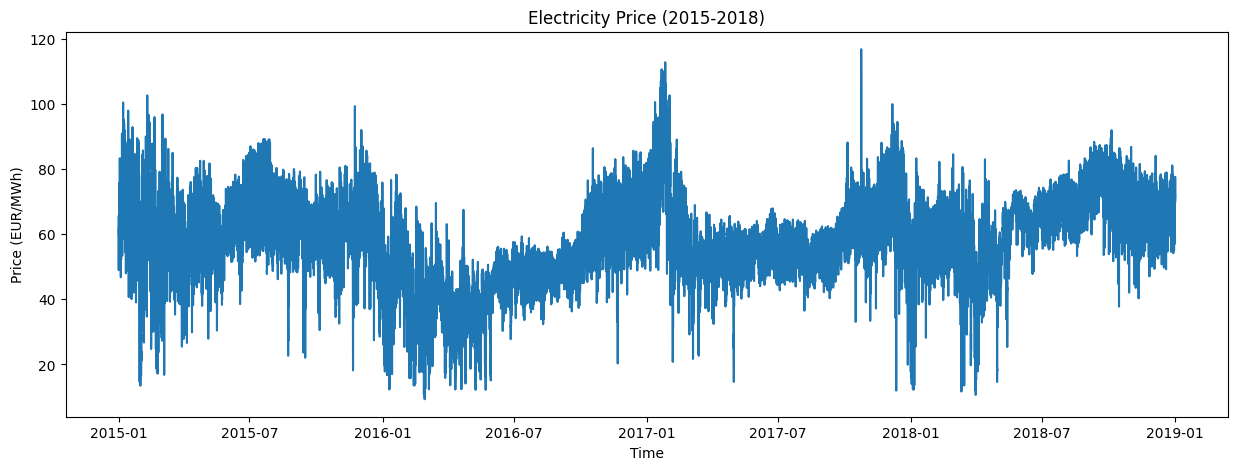

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['price actual'])
plt.title('Electricity Price (2015-2018)')
plt.xlabel('Time')
plt.ylabel('Price (EUR/MWh)')
plt.show()

I observe a noisy signal that is not easy to exploit. However, the picks are often reached during winter. It seems normal because of the big need of electricity during this season for heating and lights.

Let's now look what happens when focusing on a week. I arbitrarily put in parameter the very first week of June 2015.

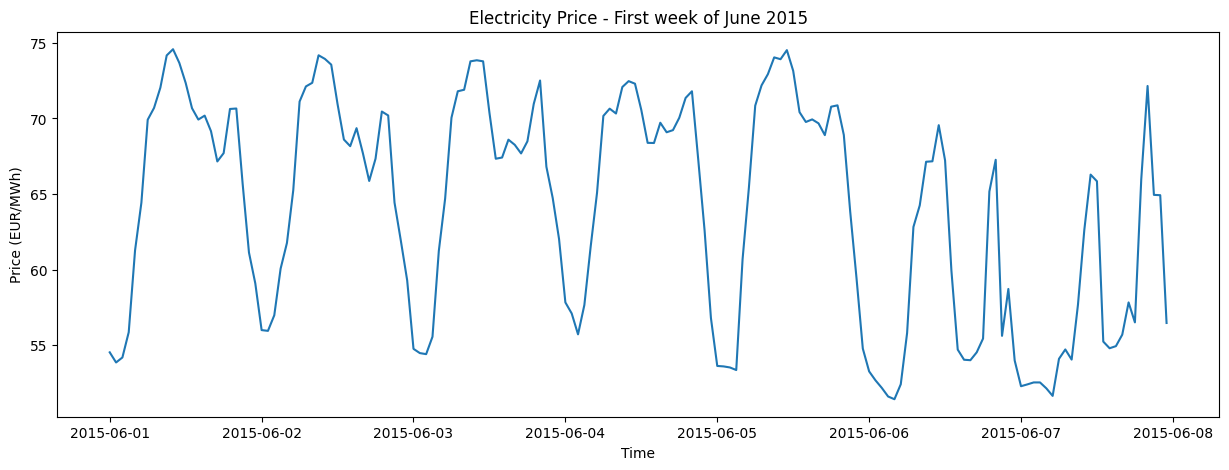

In [18]:
week = df.loc['2015-06-01':'2015-06-07']

plt.figure(figsize=(15, 5))
plt.plot(week.index, week['price actual'])
plt.title('Electricity Price - First week of June 2015')
plt.xlabel('Time')
plt.ylabel('Price (EUR/MWh)')
plt.show()

I notice repeating daily pattern: price low overnight, rising through the morning, often a dip around midday, rising again in early evening, then falling overnight again. This daily rhythm is the fingerprint of electricity demand (people wake up, go to work, cook dinner, sleep)

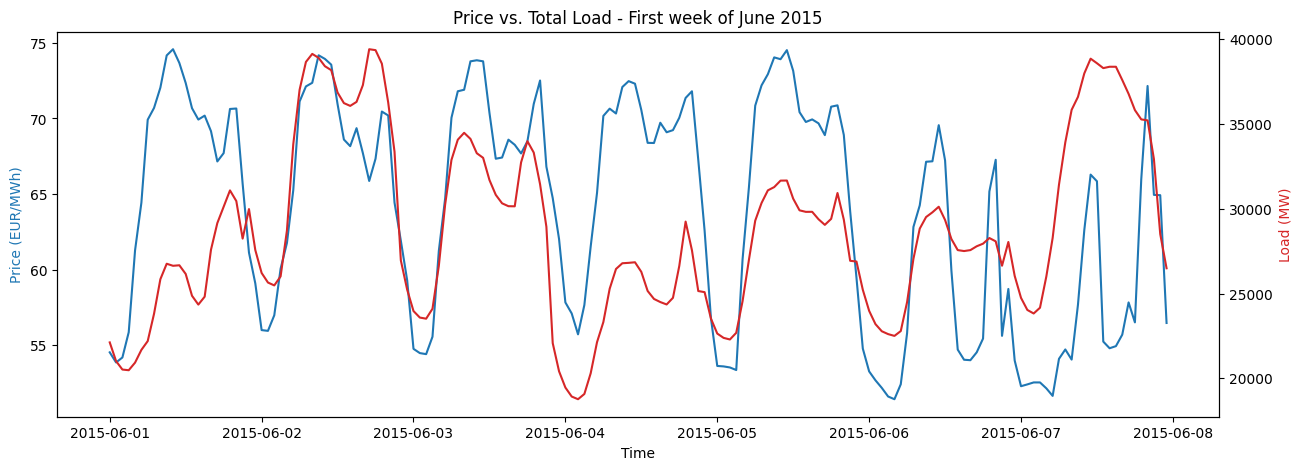

In [19]:
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(week.index, week['price actual'], color='tab:blue', label='Price (EUR/MWh)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Price (EUR/MWh)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(week.index, week['total load actual'], color='tab:red', label='Load (MW)')
ax2.set_ylabel('Load (MW)', color='tab:red')

plt.title('Price vs. Total Load - First week of June 2015')
plt.show()

The price does not follow linearly the price. I see a corelation between both signals but I want to understand why the last day (June 7th) they are that unlincked whereas the second day (June 2nd) they were more corelated.
Therefore, I focus on the last day to try to understand what could have happened.

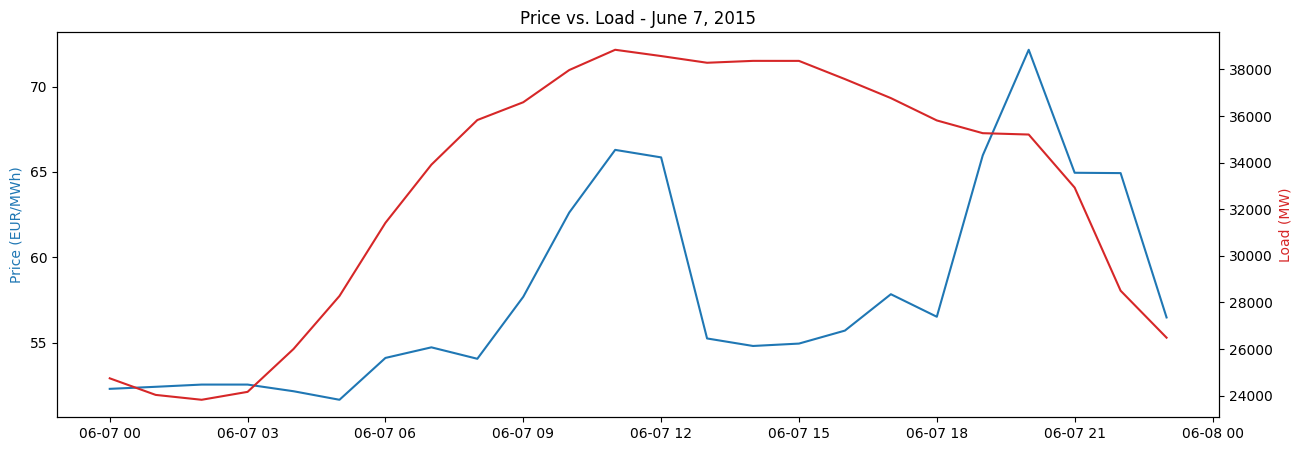

In [20]:
day1 = df.loc['2015-06-07']

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(day1.index, day1['price actual'], color='tab:blue', label='Price')
ax1.set_ylabel('Price (EUR/MWh)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(day1.index, day1['total load actual'], color='tab:red', label='Load')
ax2.set_ylabel('Load (MW)', color='tab:red')

plt.title('Price vs. Load - June 7, 2015')
plt.show()

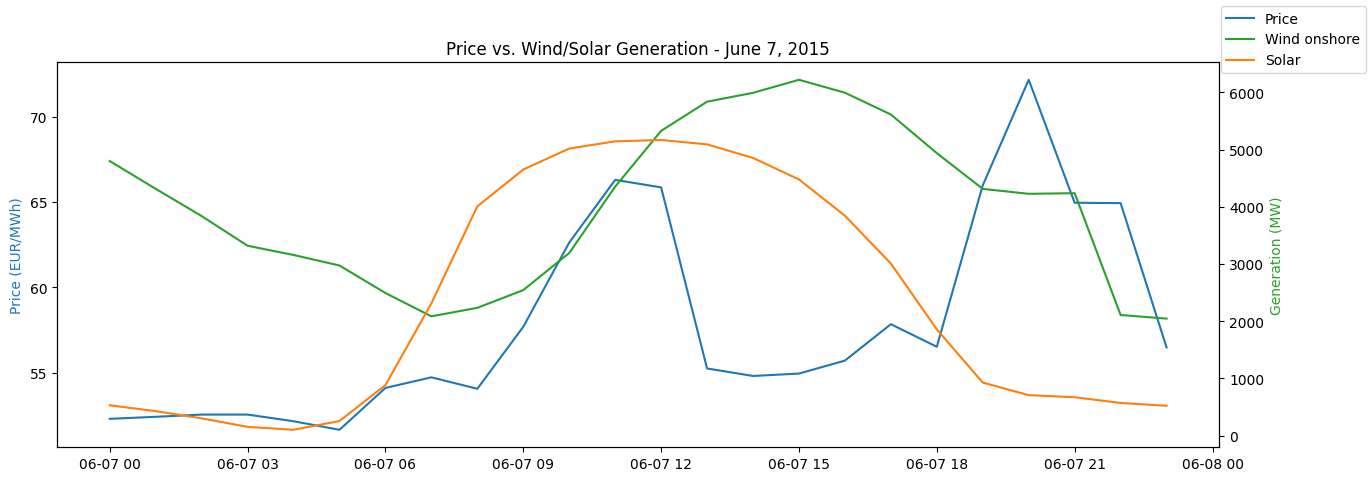

In [21]:
fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(day1.index, day1['price actual'], color='tab:blue', label='Price')
ax1.set_ylabel('Price (EUR/MWh)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(day1.index, day1['generation wind onshore'], color='tab:green', label='Wind onshore')
ax2.plot(day1.index, day1['generation solar'], color='tab:orange', label='Solar')
ax2.set_ylabel('Generation (MW)', color='tab:green')

fig.legend(loc='upper right')
plt.title('Price vs. Wind/Solar Generation - June 7, 2015')
plt.show()

A few clear patterns jump out:

1. Midday: price drops while solar peaks (11:00–15:00)
Price falls from 66 EUR/MWh down to 55 EUR/MWh right as solar climbs to its daily maximum(~5000 MW). This is the merit-order effect in action: solar has near-zero marginal cost, so when it floods the grid at midday, it pushes expensive plants out of the mix, and price drops — even though wind is also rising through this period. This midday price dip caused by solar is well documented enough to have a name: the "duck curve" effect.

2. Evening: price spikes as solar disappears (18:00–20:00)
Price shoots up to ~72 (the day's peak) right as solar collapses toward zero after 18:00. Wind is still fairly high and slowly declining, but it's not enough to offset the loss of solar plus (presumably) evening demand ramping up as people get home from work. The grid has to call on more expensive plants — this is the "neck" of the duck curve, the steepest, most expensive ramp of the day.

3. Early morning (00:00–06:00): everything is low and flat
Low price, low solar (obviously, it's dark), moderate-but-declining wind. Consistent with low overnight demand.

--> Price doesn't just track demand — it tracks demand relative to how much cheap generation (solar/wind) is available. A day with strong solar can have lower prices at high demand (midday) than a day with weak solar has at lower demand — because what matters is the gap that expensive plants have to fill.

That's why I define just after the residual load. It is the load the grid has to support once solar and wind energy sources have been taken into account.

In [23]:
#Creating a new column in the data frame to access to residual load
df['residual load'] = df['total load actual'] - df['generation solar'] - df['generation wind onshore'] - df['generation wind offshore']

Let's see if price tracks better residual load signal than it did for raw load.

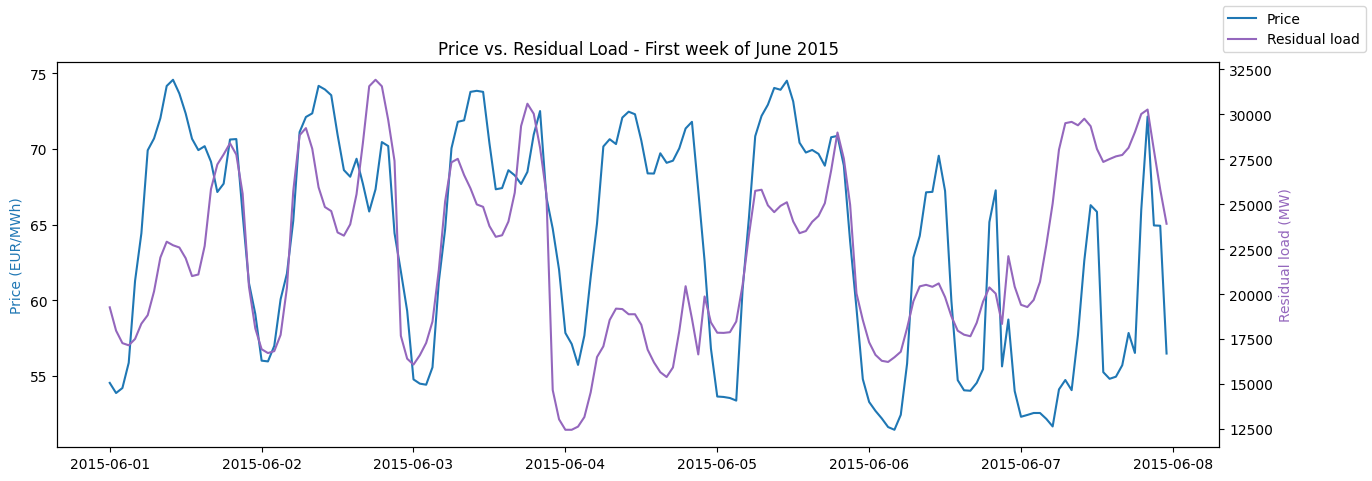

In [24]:
week = df.loc['2015-06-01':'2015-06-07']

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(week.index, week['price actual'], color='tab:blue', label='Price')
ax1.set_ylabel('Price (EUR/MWh)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(week.index, week['residual load'], color='tab:purple', label='Residual load')
ax2.set_ylabel('Residual load (MW)', color='tab:purple')

fig.legend(loc='upper right')
plt.title('Price vs. Residual Load - First week of June 2015')
plt.show()

I define here a numerical metric to compare it more accurately: **Pearson correlation coefficient** (a number between -1 and +1. +1 means they move perfectly together, -1 means perfectly opposite, 0 means no linear relationship).

In [25]:
df[['price actual', 'total load actual', 'residual load']].corr()

,price actual,total load actual,residual load
price actual,1.000000,0.435253,0.506532
total load actual,0.435253,1.000000,0.756171
residual load,0.506532,0.756171,1.000000


## Interpreting the residual load vs. price relationship

The correlation between price and total load actual is 0.44, while the correlation
between price and residual load (load minus solar and wind generation) is 0.51.
This confirms the intuition from the merit-order model of electricity pricing:
price is driven less by raw demand and more by demand net of the cheap,
near-zero-marginal-cost renewable sources (solar and wind). When solar and wind
output is high, less expensive generation is needed to meet demand, which pushes
price down even if load itself is high — this is visible on June 7, 2015, where
price drops around midday as solar output peaks, then spikes in the early evening
as solar collapses toward zero.

That said, a correlation of 0.51 is moderate, not strong — it corresponds to
residual load explaining only about 26% of the variance in price (0.51² ≈ 0.26).
The relationship is real but partial. A large share of price movement is likely
driven by factors this dataset doesn't capture directly, such as fuel costs
(gas and coal prices), which specific plant type is setting the margin at a
given hour, cross-border electricity trade, and the fact that day-ahead prices
are actually set using *forecast* generation rather than the actual generation
used here. Pearson correlation also only captures linear relationships, so it
may understate the effect of sharp, threshold-like price spikes such as the one
seen on the evening of June 7.

Next step: bring in generation by source (nuclear, gas, coal) to see which
specific sources are most associated with price spikes, and/or compare
forecast vs. actual renewable generation to explore the day-ahead pricing angle.

I just want to build a scatter plot to actually see the noise behind that 0.51 correlation.

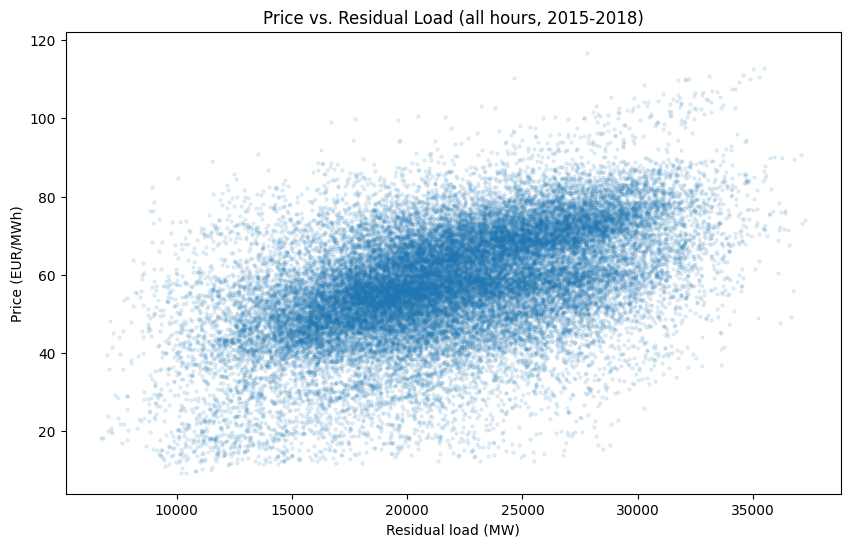

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(df['residual load'], df['price actual'], alpha=0.1, s=5)
plt.xlabel('Residual load (MW)')
plt.ylabel('Price (EUR/MWh)')
plt.title('Price vs. Residual Load (all hours, 2015-2018)')
plt.show()

## Interpreting the scatter plot

The scatter plot of residual load vs. price actual (all 35,064 hours) makes the
0.51 correlation visible. There is a clear upward trend: as residual load
increases from around 5,000 to 37,000 MW, the center of the point cloud rises
from roughly 45 EUR/MWh to 75-80 EUR/MWh. This confirms the relationship is real.

However, the cloud is wide rather than a tight line. At a fixed residual load
value (e.g. 20,000 MW), price still ranges from about 30 to 90 EUR/MWh. This
large spread at any given x-value is what a moderate correlation like 0.51 looks
like visually — a genuine trend with a lot of variance left unexplained on top
of it. If residual load alone drove price, the cloud would collapse into a thin
diagonal line instead.

There are no extreme outliers sitting apart from the main cloud — high-price
hours like the June 7, 2015 evening spike are on the upper edge of a naturally
wide distribution, not isolated anomalies. The cloud also appears to curve
slightly (steeper at low residual load, flatter at high residual load), which
suggests the true relationship may not be purely linear — something a single
Pearson correlation coefficient would not fully capture.

Next step: bring in specific generation sources (nuclear, gas) to see whether
they explain more of this remaining spread than residual load alone.